<a href="https://colab.research.google.com/github/ksailesh/housing_price_project/blob/main/Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Read the Datasets

In [19]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive/')

df_enriched_features_file_path = '/content/drive/MyDrive/Colab Notebooks/df_enriched_features.pkl'
df_without_enriched_features_file_path = '/content/drive/MyDrive/Colab Notebooks/df_without_enriched_features.pkl'
try:
  df_enriched_features = pd.read_pickle(df_enriched_features_file_path)
  display(df_enriched_features.dtypes)
  df_without_enriched_features = pd.read_pickle(df_without_enriched_features_file_path)
  display(df_without_enriched_features.dtypes)
  print("Successfully loaded the pickle files.")
except FileNotFoundError:
  print(f"Error: File not found at {df_enriched_features_file_path}. Please check the file path.")
  print(f"Error: File not found at {df_without_enriched_features_file_path}. Please check the file path.")
except Exception as e:
  print(f"An error occurred: {e}")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


,0
longitude,float64
latitude,float64
housing_median_age,int64
total_rooms,int64
total_bedrooms,Int64
population,int64
households,int64
median_income,float64
median_house_value,int64
rooms_per_household,float64


,0
longitude,float64
latitude,float64
housing_median_age,int64
total_rooms,int64
total_bedrooms,Int64
population,int64
households,int64
median_income,float64
median_house_value,int64
ocean_proximity_INLAND,bool


Successfully loaded the pickle files.


In [16]:
# df_enriched_features.loc[:, 'income_x_population'] = df_enriched_features['median_income'] * df_enriched_features['population_per_household']
# df_enriched_features.loc[:, 'pop_x_bedroom_ratio'] = df_enriched_features['population_per_household'] * df_enriched_features['bedrooms_per_room']
# df_enriched_features.loc[:, 'rooms_x_bedrooms'] = df_enriched_features['rooms_per_household'] * df_enriched_features['bedrooms_per_household']
# df_enriched_features.loc[:, 'income_x_ocean_proximity'] = df_enriched_features['median_income'] * df_enriched_features['ocean_proximity_INLAND']
# df_enriched_features.loc[:, 'ocean_x_rooms'] = df_enriched_features['ocean_proximity_NEAR OCEAN'] * df_enriched_features['rooms_per_household']
# df_enriched_features.loc[:, 'ocean_x_rooms'] = df_enriched_features['ocean_proximity_NEAR OCEAN'] * df_enriched_features['rooms_per_household']

# # Define the independent and dependent variables
# # X = df_enriched_features
# df_enriched_features = df_enriched_features[[
#                           'longitude', 'latitude',
#                           # 'ocean_proximity_NEAR OCEAN', 'rooms_per_household', 'pop_x_bedroom_ratio',
#                           # 'income_per_population',  'rooms_x_bedrooms',  'ocean_proximity_INLAND', 'income_x_population',
#                           'housing_median_age', 'households', 'median_income', 'ocean_proximity_NEAR BAY', 'income_x_ocean_proximity',
#                           'bedrooms_per_room', 'population_per_household', 'bedrooms_per_household', 'ocean_x_rooms'
#                           ]]

# Neural Network Model

In [20]:
# Generate the neural network model to predict the housing price using df_enriched_features dataframe

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Assuming 'median_house_value' is the target variable
X = df_without_enriched_features.drop('median_house_value', axis=1)
y = df_without_enriched_features['median_house_value']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
# scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Define the neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae']) # Mean Squared Error and Mean Absolute Error

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


418/418 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 55125663744.0000 - mae: 205286.6250 - val_loss: 53183086592.0000 - val_mae: 200865.2500
Epoch 2/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 51321401344.0000 - mae: 196740.0469 - val_loss: 39098122240.0000 - val_mae: 168347.0938
Epoch 3/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 34581135360.0000 - mae: 155847.1719 - val_loss: 20223854592.0000 - val_mae: 111963.3203
Epoch 4/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 17194481664.0000 - mae: 102455.1406 - val_loss: 11687717888.0000 - val_mae: 81912.8594
Epoch 5/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10876187648.0000 - mae: 79615.8438 - val_loss: 9820556288.0000 - val_mae: 74565.8750
Epoch 6/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9346258944.0000 - mae: 72367.0391 - val_loss: 8927168512.0000 - val_mae: 70357.2969
Epoch 7/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8332333056.0000 - mae: 67743.9141 - val_loss: 8270157824.0000 - val_mae

# Evaluate Model Performance

116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4308431872.0000 - mae: 46831.5703
Mean Absolute Error on test set: 46727.5703125
loss on test set: 4341216256.0
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


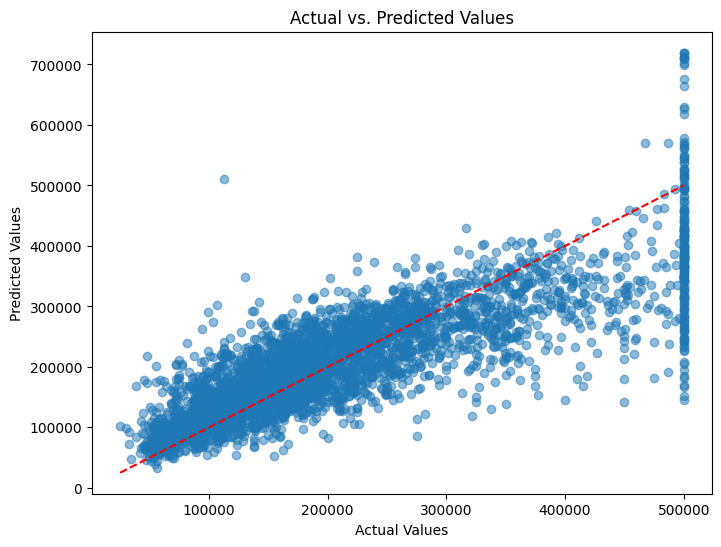

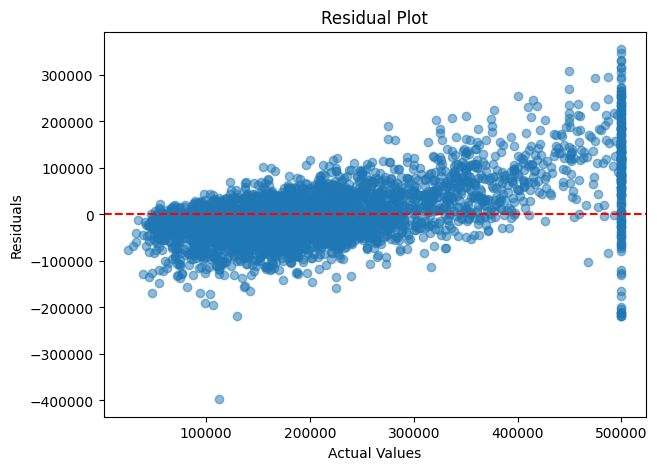

In [21]:
# Evaluate the model
loss, mae = model.evaluate(X_test, y_test)
print(f"Mean Absolute Error on test set: {mae}")
print(f"loss on test set: {loss}")

# Compare actual and predicted values using scatter plot
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = model.predict(X_test)

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.show()

# Reshape y_pred to be 1-dimensional
y_pred = y_pred.flatten()

# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(7, 5))
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='dashed')
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()